<a href="https://colab.research.google.com/github/gitmystuff/INFO5810/blob/main/Module_07-Graph_Machine_Learning/Graph_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning from Networks: Graph Machine Learning

Your Name

## Getting Started

* Colab - get notebook from gitmystuff INFO5810 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name in the cell above and the filename
* Clean up Colab Notebooks folder
* Submit shared link

## Where we are, and where we're going

Last week we asked: **can you tell which side of a network a member belongs to, just by looking at who's connected to whom?** We built one number per member, straight from the friendship list (the Fiedler score), and it split the club into its two real sides.

This week's question is a small but important shift: **can a machine *learn* that same kind of number, instead of us solving for it directly?** And once a member has a learned number (or a short list of numbers), can we use it to guess friendships that were never told to us?

That second question is exactly this week's guided activity: **run a Graph Neural Network to predict missing connections in a network.**

**The plan, in nine short parts:**

0. A quick puzzle: two members with identical friends — should a machine treat them the same?
1. What a "node embedding" is, in one picture.
2. Node2Vec — learning from random walks (a direct callback to PageRank).
3. A fast recap of last week's number (the Fiedler score), stated as plainly as possible.
4. A Graph Neural Network (GCN) — the same friendship matrix from last week, now *learned into* instead of solved.
5. Using the GCN to predict hidden friendships — this week's guided activity.
6. GraphSAGE — a second way to learn from neighbors, compared to GCN.
7. A brief look at TransE — embedding relationships, not just members.
8. A quiet bug that can make a result look better than it really is.

Same rule as always: **overview, not mastery.** You won't memorize the code. You'll learn what question each piece answers, and how to tell if the answer is any good.

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# This week we also need PyTorch and PyTorch Geometric, which are not preinstalled in Colab.
%pip install torch torch_geometric gensim plotly -q

import torch
import torch.nn.functional as F
print("torch", torch.__version__, "| GPU available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 45.2 MB/s eta 0:00:00
torch 2.11.0+cu128 | GPU available: True


**A note on that last line.** If it says `GPU available: False`, that's fine — everything in this notebook is small enough to train on a plain CPU in a few seconds. If you want to try a GPU runtime anyway: `Runtime` → `Change runtime type` → `T4 GPU`.

---
## Part 0 — A puzzle: do identical friends deserve identical treatment?

Recall from last week: members 14, 15, 18, 20, and 22 all share the *exact same two friends* — members 32 and 33, and nobody else. From the network's point of view, these five members are interchangeable.

Here's this week's puzzle. Suppose a member starts out knowing only one thing about themselves: how many friends they have. Nothing else — no name, no history, just a single number. Now let a very small neural network look at the graph and update that number based on what its friends currently have. Before we've trained anything at all — no learning, no data about the real club — what happens to these five members?

In [ ]:
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx

K = nx.karate_club_graph()
for _, _, d in K.edges(data=True):
    d.pop("weight", None)
nodes = list(K.nodes)
n = len(nodes)

data = from_networkx(K)                       # hands the graph to PyTorch Geometric
deg = np.array([d for _, d in K.degree()], dtype=np.float32)
x0 = torch.tensor(deg, dtype=torch.float32).view(-1, 1)   # each member starts knowing only their friend count

class TinyGCN(torch.nn.Module):
    def __init__(self, in_dim, hidden):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

torch.manual_seed(0)
untrained = TinyGCN(in_dim=1, hidden=4)
with torch.no_grad():
    out = untrained(x0, data.edge_index)

same_friends = [14, 15, 18, 20, 22]
print("Do members 14, 15, 18, 20, 22 really share the same two friends?")
for m in same_friends:
    print(f"  member {m}: friends = {sorted(K[m])}")

print()
print("Their numbers after passing through an UNTRAINED network:")
for m in same_friends:
    print(f"  member {m}: {out[m].numpy().round(4)}")

Do members 14, 15, 18, 20, 22 really share the same two friends?
  member 14: friends = [32, 33]
  member 15: friends = [32, 33]
  member 18: friends = [32, 33]
  member 20: friends = [32, 33]
  member 22: friends = [32, 33]

Their numbers after passing through an UNTRAINED network:
  member 14: [-2.5647  2.2383 -3.1409  2.2297]
  member 15: [-2.5647  2.2383 -3.1409  2.2297]
  member 18: [-2.5647  2.2383 -3.1409  2.2297]
  member 20: [-2.5647  2.2383 -3.1409  2.2297]
  member 22: [-2.5647  2.2383 -3.1409  2.2297]


**Reading the output.** All five members really do have exactly `[32, 33]` as their only two friends. And look at their output: all five come out with the **exact same four numbers**, to the last decimal — even though we haven't trained anything.

Why? Because the network's whole rule is: *your new numbers depend only on your friends' numbers.* Five members with identical friends, and no other information about who they are, must get identical treatment. There's nowhere for a difference to come from.

That's the idea for the whole week, before a single line of training happens: **birds of a feather flock together, automatically, just from the shape of who's-friends-with-who.** Training, later in this notebook, is only there to make that automatic behavior *useful* — for example, for guessing hidden friendships.

---
## Part 1 — From one number to a short list of numbers

Last week, every member got **one** number — the Fiedler score. That one number could split the club into two sides.

This week's methods give every member a **short list of numbers** instead — say, 8 or 16 numbers per member. This list is called a **node embedding**. Why more than one number?

Think of it this way: one number can only place a member on a line (positive side, negative side, or in between). A short list of numbers places a member in a small space, the way three numbers place a point in a room instead of just on a wall. That extra room means embeddings can capture more than just "which of two sides" — they can capture finer shades of belonging, several groups at once, or which specific fellow members you resemble most.

Everything from here is really answering one question: **where do these lists of numbers come from, and how do we know if they're any good?**

---
## Part 2 — Node2Vec: learning from random walks

Recall PageRank's wanderer from last week: stand on a member, look at their friends, pick one at random, walk there, repeat. PageRank used that wanderer to count *how often* each member gets visited.

**Node2Vec reuses that exact same wanderer, but writes down the path instead of just counting visits.**

In [ ]:
rng = np.random.default_rng(0)

def random_walk(G, start, length, rng):
    walk = [start]
    for _ in range(length - 1):
        friends = list(G[walk[-1]])
        walk.append(friends[rng.integers(len(friends))])
    return walk

one_walk = random_walk(K, start=0, length=10, rng=rng)
print("one walk, starting at member 0:")
print(one_walk)

one walk, starting at member 0:
[0, 19, 1, 13, 1, 3, 0, 2, 0, 3]


That list of ten member numbers is the walk. Nothing new yet — it's the same wanderer, just with a memory.

**Now call each walk a "sentence."** Each member visited is like a word. A walk is a sentence made of members instead of English words:

| | A real sentence | A walk |
|---|---|---|
| Made of | words, in order | members, in order |
| Example | "the cat sat on the mat" | 0, 8, 30, 33, 22, 32, 8, 33, 22, 32 |
| Order matters? | yes | yes — it's the actual path the wanderer took |

**Do this many times, starting from every member**, and we get a whole pile of "sentences."

In [ ]:
walks = []
for start in nodes:
    for _ in range(20):                                 # 20 walks from every starting member
        walks.append([str(m) for m in random_walk(K, start, length=10, rng=rng)])

print(f"{len(walks)} walks generated. Three examples:")
for w in walks[:3]:
    print(" ", w)

680 walks generated. Three examples:
  ['0', '19', '1', '30', '32', '23', '33', '29', '32', '22']
  ['0', '10', '5', '6', '16', '6', '0', '7', '3', '7']
  ['0', '1', '19', '33', '31', '24', '25', '31', '0', '10']


**Reuse Module 3's trick.** Back in Module 3, word2vec learned that words showing up in similar sentences end up with similar vectors ("king" and "queen" appear in similar contexts, so they land near each other). Node2Vec trains the *exact same way* — the only difference is that our "sentences" are these walks, and our "words" are member numbers instead of English words.

In [ ]:
from gensim.models import Word2Vec

n2v_model = Word2Vec(
    sentences=walks,
    vector_size=8,      # each member gets a list of 8 numbers
    window=3,            # "nearby in the sentence" means within 3 steps
    min_count=0,
    sg=1,                 # skip-gram, the same training style word2vec used in Module 3
    workers=1,
    seed=0,
    epochs=20,
)

embeddings = np.array([n2v_model.wv[str(m)] for m in nodes])
print("embedding table shape:", embeddings.shape, "(34 members, 8 numbers each)")
print("member 0's embedding:", embeddings[0].round(3))

embedding table shape: (34, 8) (34 members, 8 numbers each)
member 0's embedding: [-0.567  0.064 -0.116  0.575 -0.076  0.84   0.582  0.678]


**Check it, the same way we checked the Fiedler score last week.** Members 14, 15, 18, 20, and 22 share identical friends. If Node2Vec is doing what we claim, their embeddings should end up very close together — even though this method never solved any equation, it only trained on walks.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

same_friends = [14, 15, 18, 20, 22]
similarity = cosine_similarity(embeddings[same_friends])

print("How similar are the identical-neighbor members' embeddings? (1.0 = identical direction)")
display(pd.DataFrame(similarity.round(3), index=same_friends, columns=same_friends))

How similar are the identical-neighbor members' embeddings? (1.0 = identical direction)


,14,15,18,20,22
14,1.000,0.991,0.969,0.990,0.993
15,0.991,1.000,0.943,0.981,0.975
18,0.969,0.943,1.000,0.970,0.977
20,0.990,0.981,0.970,1.000,0.976
22,0.993,0.975,0.977,0.976,1.000


**Reading the output.** Every pair among these five members scores above 0.96 — nearly identical, purely from walking around the graph and training on the paths. Nobody told the training process these five were special; it discovered it from how often they showed up in similar walks.

**One more check: does this recover the real two-sided split?** We'll use the real answer only to grade the result, exactly as we did last week.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

truth = np.array([1 if K.nodes[i]["club"] == "Mr. Hi" else 0 for i in nodes])
guess = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(embeddings)

print("How well do the Node2Vec embeddings recover the real split?")
print("ARI:", round(adjusted_rand_score(truth, guess), 3), "  (1.0 = perfect match, 0 = no better than guessing)")

How well do the Node2Vec embeddings recover the real split?
ARI: 0.772   (1.0 = perfect match, 0 = no better than guessing)


An ARI of about 0.77 says the embeddings recover the real split quite well — not perfectly, but clearly far better than chance. No eigenvectors were involved anywhere in this section. We walked around the graph, wrote down the paths, and trained on them the way we'd train on sentences of text.

> **Big idea.** A walk is a sentence, and a member is a word. Train the same way you'd train on real text, and members who show up in similar company end up with similar embeddings.

---
## Part 3 — Last week's number, one more time, as plainly as possible

Before we build a network that *learns* embeddings, let's nail down exactly what we were doing last week, since everything from here builds on it.

**The input was one matrix: who's friends with whom.** Thirty-four rows, thirty-four columns, filled with 0s and 1s.

In [ ]:
A = nx.to_numpy_array(K, nodelist=nodes)
print("The friendship matrix (first 6 members shown):")
display(pd.DataFrame(A[:6, :6].astype(int), index=range(6), columns=range(6)))

The friendship matrix (first 6 members shown):


,0,1,2,3,4,5
0,0,1,1,1,1,1
1,1,0,1,1,0,0
2,1,1,0,1,0,0
3,1,1,1,0,0,0
4,1,0,0,0,0,0
5,1,0,0,0,0,0


That's the entire input. A grid of 0s and 1s, nothing else.

**From that matrix alone, one specific list of 34 numbers can be solved for directly** — no guessing, no trial and error. That list is called an **eigenvector**, and it's the answer to one question: *what numbers can we give the members so that friends end up as close in value as possible?*

In [ ]:
L = np.diag(A.sum(axis=1)) - A                  # a grid built from the friendship matrix
eigvals, eigvecs = np.linalg.eigh(L)
fiedler = eigvecs[:, 1].copy()
if fiedler[0] < 0:
    fiedler = -fiedler

print("The friendship matrix goes in, this list of 34 numbers comes out:")
print(np.round(fiedler[:8], 3), "...")

The friendship matrix goes in, this list of 34 numbers comes out:
[ 0.112  0.041 -0.023  0.055  0.285  0.324  0.324  0.053] ...


**A natural first guess: does having more friends give you a bigger number?** Let's test that directly, on the two members it should show up most clearly for — the member with the most friends in the whole club, and a member with almost none.

In [ ]:
degree = A.sum(axis=1)
table = pd.DataFrame({
    "friends":  degree[[16, 0, 33, 8]].astype(int),
    "fiedler score": fiedler[[16, 0, 33, 8]].round(3),
}, index=["member 16", "member 0", "member 33", "member 8"])
display(table)

,friends,fiedler score
member 16,2,0.423
member 0,16,0.112
member 33,17,-0.119
member 8,5,-0.052


**Reading the table.** Member 33 has the *most* friends in the whole club — 17 — and gets a *negative* number. Member 16 has only 2 friends and gets the *biggest* number in the club. So it isn't "more friends, bigger number." The correlation between friend-count and this score, across all 34 members, is essentially zero.

**What actually decides the number is whether your friends agree with each other.**

In [ ]:
truth = np.array([1 if K.nodes[i]["club"] == "Mr. Hi" else 0 for i in nodes])   # the real-world side, known only for checking

def friend_agreement(member):
    friends = sorted(K[member])
    same_side = sum(1 for f in friends if truth[f] == truth[member])
    return f"{same_side} of {len(friends)}"

table2 = pd.DataFrame({
    "friends who share their own real side": [friend_agreement(m) for m in [16, 0, 33, 8]],
    "fiedler score": fiedler[[16, 0, 33, 8]].round(3),
}, index=["member 16", "member 0", "member 33", "member 8"])
display(table2)

,friends who share their own real side,fiedler score
member 16,2 of 2,0.423
member 0,15 of 16,0.112
member 33,14 of 17,-0.119
member 8,2 of 5,-0.052


**Reading this table.** Member 16's two friends *both* agree with member 16 about which side they're on — and member 16 gets the strongest score in the club. Member 8's friends are split (only 2 of 5 agree) — and member 8's score is small and lands on the wrong side. **The number is large and confident when your friends mostly agree with each other and you're one of them. It's small, or flipped, when your friends are split.**

**Here's that same idea, drawn out for all 34 members at once.** This time we give each member *two* solved numbers instead of one, so we can place them on a flat picture instead of a line.

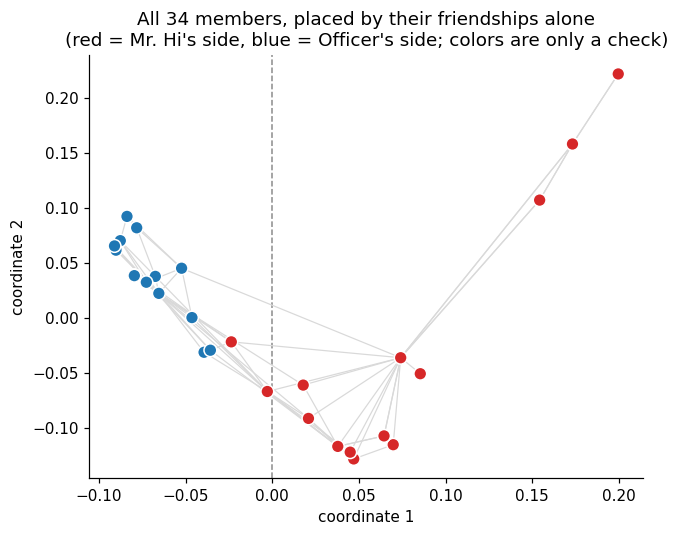

In [ ]:
from sklearn.manifold import SpectralEmbedding

emb2d = SpectralEmbedding(n_components=2, affinity="precomputed", random_state=0).fit_transform(A)
if emb2d[0, 0] < 0:
    emb2d[:, 0] *= -1

fig, ax = plt.subplots(figsize=(6.5, 5))
for u, v in K.edges:
    ax.plot(*zip(emb2d[u], emb2d[v]), color="0.85", lw=0.8, zorder=1)
ax.scatter(emb2d[:, 0], emb2d[:, 1], c=np.where(truth == 1, "tab:red", "tab:blue"), s=70, zorder=2, edgecolors="white")
ax.axvline(0, color="0.55", ls="--", lw=1, zorder=0)
ax.set_xlabel("coordinate 1"); ax.set_ylabel("coordinate 2")
ax.set_title("All 34 members, placed by their friendships alone\n(red = Mr. Hi's side, blue = Officer's side; colors are only a check)")
plt.show()

**Reading the picture.** The dashed line is where the sign flips — the same split as the table above. Members sitting deep in red or deep in blue territory are firmly on their side. Members near the line are the borderline cases (this is exactly where members 2 and 8 from last week show up). This is what last week's method gives us: two numbers, solved directly, for every member, all at once.

That's what last week's number really measures. Now, the vocabulary:

> This list of 34 numbers has a name: it's an **eigenvector**. An eigenvector is just the one special direction a matrix doesn't turn — feed it in, and what comes out points the same way, only longer or shorter. The friendship matrix has one direction like that, and that direction is our Fiedler score.

**Last week we solved for this eigenvector directly, in one shot.** This week, a Graph Neural Network is going to learn something similar a different way: instead of solving for the answer all at once, it starts with a rough set of numbers and nudges them, a little at a time, toward its neighbors — over and over, through training. Let's watch that happen.

---
## Part 4 — GCN: the same matrix, now learned into instead of solved

Here's the reuse we've been building toward: **the exact same 34×34 friendship matrix from Part 3 becomes the input to our first Graph Neural Network.** Nothing new is built. Same members, same friendships, same matrix.

A **Graph Convolutional Network (GCN)** does something we already saw in Part 0: every member's numbers get updated to be a mix of their own numbers and their friends' numbers. One layer of that is one round of "move toward your friends." Stack a couple of layers, and information can travel two friendships away. Do this over many rounds of training — adjusting the mixing rule so it gets better at some task — and the numbers settle somewhere useful.

Let's watch a member's numbers move, layer by layer, starting from nothing but its friend count.

### Neural Net Review

1. **A network is just a mixing rule with adjustable knobs.** We already said a GCN layer "mixes each member with their friends (combining their own current number with their friends' current numbers)" — the missing piece is that *how much* it mixes is controlled by numbers inside the layer, and those numbers start out random.
2. **Training means nudging those knobs to make a specific mistake smaller.** One tiny example, maybe even simpler than the graph — a single adjustable number, one clear "right answer," and a plot of the mistake shrinking as we nudge it. This is the same shape as the loss curve already in Part 5, just isolated and slowed down.
3. **"Loss" is just a name for the size of the mistake.** One number, lower is better — exactly how the Part 5 loss curve is already labeled, but said explicitly before that plot shows up.
4. **Backpropagation, in one sentence:** it's the method for figuring out *which direction* to nudge each knob to make the loss go down. No calculus, no chain rule — just "the network can tell which way to turn each knob."
5. **One pass of nudging = one training round (an epoch).** Do it hundreds of times, and the knobs settle somewhere useful — which is exactly what the loss curve shows happening.

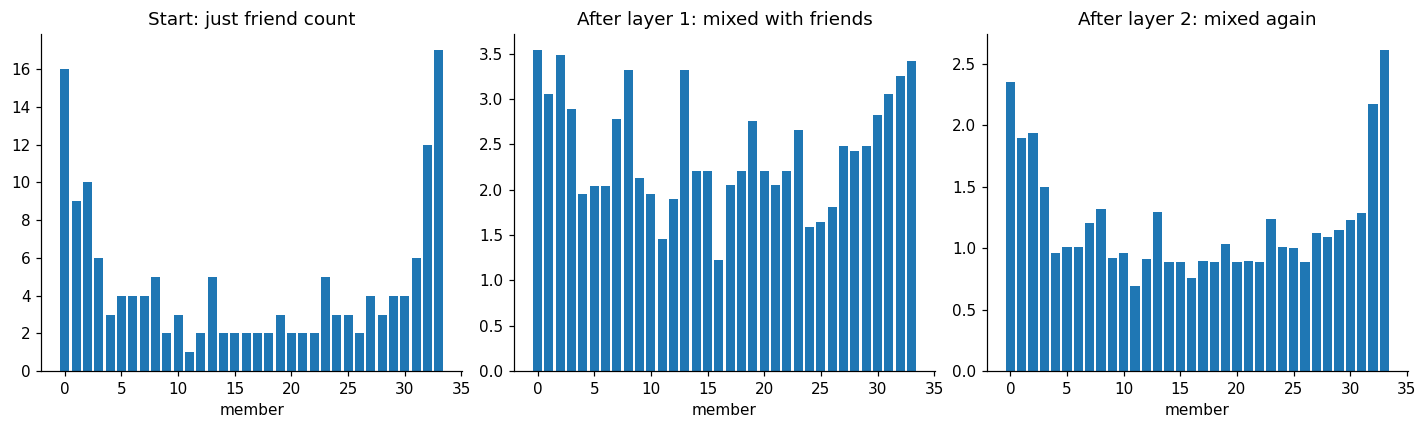

In [ ]:
class SmallGCN(torch.nn.Module):
    def __init__(self, in_dim, hidden):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
    def forward(self, x, edge_index):
        h1 = F.relu(self.conv1(x, edge_index))
        h2 = self.conv2(h1, edge_index)
        return h1, h2

torch.manual_seed(7)
watch_model = SmallGCN(in_dim=1, hidden=2)     # 2 numbers per member, small enough to plot directly
with torch.no_grad():
    after_layer1, after_layer2 = watch_model(x0, data.edge_index)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, vals, title in zip(
    axes,
    [x0.numpy().flatten(), after_layer1.numpy()[:, 0], after_layer2.numpy()[:, 0]],
    ["Start: just friend count", "After layer 1: mixed with friends", "After layer 2: mixed again"],
):
    ax.bar(range(n), vals, color="tab:blue")
    ax.set_title(title); ax.set_xlabel("member")
plt.tight_layout(); plt.show()

**Reading the plot.** The first panel is just each member's raw friend count — spiky, no structure. After one layer of mixing with neighbors, the bars already look smoother, since each member's number now blends in its friends' counts. After a second layer, they smooth out further, since information from two friendships away has had a chance to blend in too. This is the same "smoothing" idea from last week's Fiedler score, produced by repeated local mixing instead of solved for directly — and importantly, **no training has happened yet.** This is architecture alone.

**Training** is what turns this smoothing behavior into something *useful*. Next, we'll train a GCN with one specific goal: guess which pairs of members are secretly friends.

> **Big idea.** A GCN repeatedly mixes each member's numbers with their friends'. One layer of that is Part 0's "move toward your friends," done with numbers a computer can adjust through training.

---
## Part 5 — Link prediction: guessing hidden friendships

This is this week's guided activity: **hide some real friendships, train a network, and see if it can guess which hidden pairs were the real ones.**

**Step 1: hide 10 of the 78 real friendships**, and keep the other 68 for training.

In [ ]:
edges = list(K.edges())
idx = rng.permutation(len(edges))
n_hide = 10
hidden_edges = [edges[i] for i in idx[:n_hide]]
train_edges  = [edges[i] for i in idx[n_hide:]]

print(f"{len(edges)} real friendships total")
print(f"hiding {len(hidden_edges)} for testing:  {hidden_edges}")
print(f"training on the remaining {len(train_edges)}")

G_train = nx.Graph(); G_train.add_nodes_from(nodes); G_train.add_edges_from(train_edges)
print("training graph still fully connected:", nx.is_connected(G_train))

78 real friendships total
hiding 10 for testing:  [(2, 13), (1, 13), (30, 32), (31, 33), (0, 2), (28, 31), (0, 10), (24, 27), (2, 3), (0, 4)]
training on the remaining 68
training graph still fully connected: True


**Step 2: also pick 10 random pairs who are *not* friends**, to compare against. If our network is any good, it should score the real hidden friendships higher than these random pairs.

In [ ]:
def to_edge_index(G):
    e = np.array(G.edges())
    both_directions = np.concatenate([e, e[:, ::-1]], axis=0)
    return torch.tensor(both_directions.T, dtype=torch.long)

edge_index_train = to_edge_index(G_train)

non_friends = [(i, j) for i in range(n) for j in range(i + 1, n) if not K.has_edge(i, j)]
neg_idx = rng.choice(len(non_friends), n_hide, replace=False)
random_pairs = [non_friends[i] for i in neg_idx]
random_pairs_set = set(random_pairs)
training_negatives = [p for p in non_friends if p not in random_pairs_set]

print("10 random non-friend pairs, kept aside for testing:", random_pairs)

10 random non-friend pairs, kept aside for testing: [(2, 16), (3, 10), (4, 21), (27, 31), (6, 22), (0, 22), (5, 31), (2, 6), (14, 25), (0, 28)]


**Step 3: train a GCN with one specific goal — score real training friendships higher than random non-friend pairs.** Each member starts as one-hot: it only knows "which member number am I," nothing else. Every bit of useful information has to come from the graph structure itself.

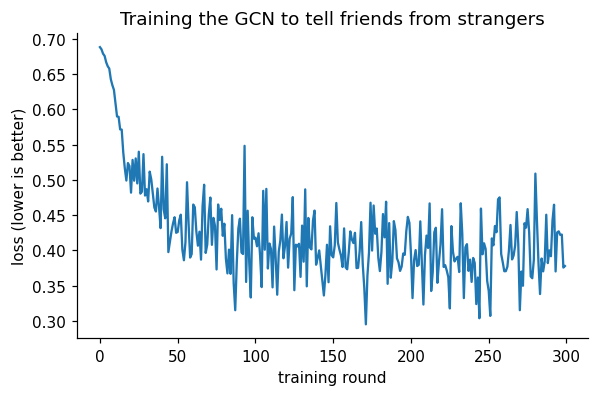

In [ ]:
def score_pairs(embedding, pairs):
    a = embedding[[p[0] for p in pairs]]
    b = embedding[[p[1] for p in pairs]]
    return (a * b).sum(dim=1)      # a simple "how alike are these two members' embeddings" score

x_identity = torch.eye(n)          # each member starts knowing only its own identity

class LinkGCN(torch.nn.Module):
    def __init__(self, in_dim, hidden, out):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, out)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

torch.manual_seed(0)
gcn = LinkGCN(in_dim=n, hidden=16, out=16)
optimizer = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)

losses = []
for epoch in range(300):
    gcn.train(); optimizer.zero_grad()
    embedding = gcn(x_identity, edge_index_train)

    pos_scores = score_pairs(embedding, train_edges)                            # real training friendships
    neg_sample = [training_negatives[i] for i in rng.choice(len(training_negatives), len(train_edges), replace=False)]
    neg_scores = score_pairs(embedding, neg_sample)                             # random non-friendships

    labels = torch.cat([torch.ones(len(pos_scores)), torch.zeros(len(neg_scores))])
    scores = torch.cat([pos_scores, neg_scores])
    loss = F.binary_cross_entropy_with_logits(scores, labels)

    loss.backward(); optimizer.step()
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(losses)
ax.set_xlabel("training round"); ax.set_ylabel("loss (lower is better)")
ax.set_title("Training the GCN to tell friends from strangers")
plt.show()

**Step 4: the real test.** Score the 10 hidden friendships (which the network never trained on) against the 10 random pairs, and see which group scores higher.

In [ ]:
gcn.eval()
with torch.no_grad():
    final_embedding = gcn(x_identity, edge_index_train)
    hidden_scores = score_pairs(final_embedding, hidden_edges)
    random_scores = score_pairs(final_embedding, random_pairs)

results = pd.DataFrame({
    "pair": [str(p) for p in hidden_edges] + [str(p) for p in random_pairs],
    "really friends?": ["yes"] * n_hide + ["no"] * n_hide,
    "GCN score": np.r_[hidden_scores.numpy(), random_scores.numpy()].round(2),
}).sort_values("GCN score", ascending=False)
display(results)

from sklearn.metrics import roc_auc_score
y_true = np.r_[np.ones(n_hide), np.zeros(n_hide)]
y_score = np.r_[hidden_scores.numpy(), random_scores.numpy()]
print("AUC:", round(roc_auc_score(y_true, y_score), 3), " (1.0 = perfect separation, 0.5 = no better than a coin flip)")

,pair,really friends?,GCN score
1,"(1, 13)",yes,2.31
8,"(2, 3)",yes,2.04
4,"(0, 2)",yes,1.82
0,"(2, 13)",yes,1.34
2,"(30, 32)",yes,1.09
19,"(0, 28)",no,0.22
12,"(4, 21)",no,-0.28
18,"(14, 25)",no,-0.35
14,"(6, 22)",no,-0.73
13,"(27, 31)",no,-0.80


AUC: 0.7  (1.0 = perfect separation, 0.5 = no better than a coin flip)


**Reading the output.** Sort the table by score, and something clean jumps out: the five highest-scoring pairs of all 20 are real hidden friendships — the network ranked every one of them above every random pair. Further down the list, the separation gets messier, and a few real friendships end up scored lower than some random pairs. That messiness is why the overall AUC lands at 0.7, not something closer to 1.0: it means that if you picked one real hidden friendship and one random pair at random, the GCN scores the real one higher about 70% of the time. It was never told which 10 edges we hid — it learned this purely from the other 68 friendships and the graph's shape.

This is not perfect, and it shouldn't be — 34 members and 68 training friendships is a tiny amount of data for a neural network, and re-running this cell with a different random split of hidden edges will move the AUC around. The result is real and honest, not a guaranteed win.

> **Big idea.** Train embeddings to score real friendships higher than random pairs, and you get a tool for guessing which unknown pairs are probably connected — exactly what recommendation systems and social networks do at a much larger scale.

---
## Comparing three ways to place a member

We've now placed the 34 members three different ways: the raw friendship matrix (34 numbers per member), last week's solved Fiedler coordinates (2 numbers per member, in the picture back in Part 3), and this week's trained GCN (16 numbers per member, in Part 5). Let's put the solved answer and the learned answer side by side — and this time, ask the GCN for just 3 numbers, small enough to actually see in 3D.

We'll train the exact same GCN from Part 5 one more time, changing only one setting: `out=3` instead of `out=16`.

In [ ]:
torch.manual_seed(0)
gcn_3d = LinkGCN(in_dim=n, hidden=16, out=3)
optimizer = torch.optim.Adam(gcn_3d.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(300):
    gcn_3d.train(); optimizer.zero_grad()
    embedding = gcn_3d(x_identity, edge_index_train)
    pos_scores = score_pairs(embedding, train_edges)
    neg_sample = [training_negatives[i] for i in rng.choice(len(training_negatives), len(train_edges), replace=False)]
    neg_scores = score_pairs(embedding, neg_sample)
    labels = torch.cat([torch.ones(len(pos_scores)), torch.zeros(len(neg_scores))])
    loss = F.binary_cross_entropy_with_logits(torch.cat([pos_scores, neg_scores]), labels)
    loss.backward(); optimizer.step()

gcn_3d.eval()
with torch.no_grad():
    embedding_3d = gcn_3d(x_identity, edge_index_train).numpy()

print("embedding shape:", embedding_3d.shape, "(34 members, 3 numbers each)")

# a quick, honest check: does this recover the real split at all?
from sklearn.cluster import KMeans as _KMeans_check
guess_3d = _KMeans_check(n_clusters=2, n_init=10, random_state=0).fit_predict(embedding_3d)
print("ARI vs real split:", round(adjusted_rand_score(truth, guess_3d), 3))

embedding shape: (34, 3) (34 members, 3 numbers each)
ARI vs real split: 0.483


First, last week's picture again, for a direct comparison:

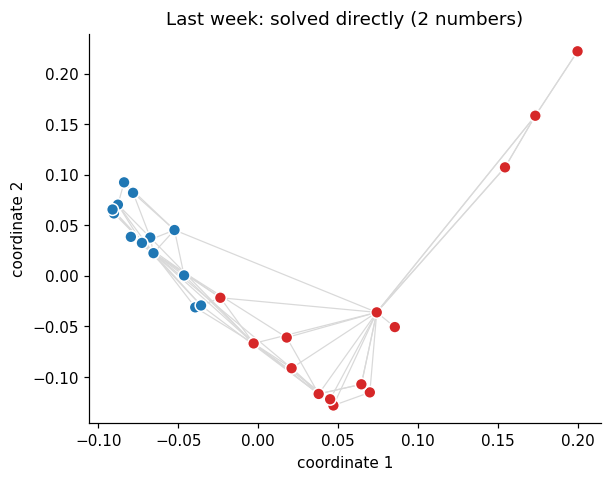

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.6))
for u, v in K.edges:
    ax.plot(*zip(emb2d[u], emb2d[v]), color="0.85", lw=0.8, zorder=1)
ax.scatter(emb2d[:, 0], emb2d[:, 1], c=np.where(truth == 1, "tab:red", "tab:blue"), s=60, zorder=2, edgecolors="white")
ax.set_title("Last week: solved directly (2 numbers)")
ax.set_xlabel("coordinate 1"); ax.set_ylabel("coordinate 2")
plt.show()

Now the same 34 members, placed by this week's **trained** GCN instead — in 3D, since we asked for 3 numbers this time. This one is interactive: click and drag to rotate it, and hover over a point to see which member it is.

In [ ]:
import plotly.graph_objects as go

edge_x, edge_y, edge_z = [], [], []
for u, v in K.edges:
    edge_x += [embedding_3d[u, 0], embedding_3d[v, 0], None]
    edge_y += [embedding_3d[u, 1], embedding_3d[v, 1], None]
    edge_z += [embedding_3d[u, 2], embedding_3d[v, 2], None]

point_colors = np.where(truth == 1, "red", "blue")

fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z, mode="lines",
    line=dict(color="lightgray", width=1), hoverinfo="none", showlegend=False,
))
fig3d.add_trace(go.Scatter3d(
    x=embedding_3d[:, 0], y=embedding_3d[:, 1], z=embedding_3d[:, 2],
    mode="markers",
    marker=dict(size=6, color=point_colors, line=dict(color="white", width=1)),
    hovertext=[f"member {m}" for m in nodes], hoverinfo="text",
    showlegend=False,
))
fig3d.update_layout(
    title="This week: learned through training (3 numbers)<br><sub>red = Mr. Hi's side, blue = Officer's side; colors are only a check</sub>",
    scene=dict(xaxis_title="coordinate 1", yaxis_title="coordinate 2", zaxis_title="coordinate 3"),
    width=750, height=600, margin=dict(l=0, r=0, b=0, t=60),
)
fig3d.show()

**Reading the picture.** Rotate it, and you'll see red and blue members leaning into different regions of the space — not two clean, separate blobs like last week's picture, but a real tendency, not random scatter either. On average, a member sits about twice as close to its own side's center as to the other side's. A few members (like 24, 25, and 21) land clearly off in their own corner, and a handful of others sit in the mixed territory in the middle.

That messiness is the honest, useful lesson here. Last week's method **solved** for the split directly, in one shot, with that split as the entire goal, and it nailed it. This week's GCN was **trained toward a different goal** — predicting hidden friendships — and the real club's two sides showed up only as a partial side effect of that training, not as the target. When you ask a method to learn one thing, don't be surprised if what you actually wanted only shows up faintly, tangled up with whatever it was actually optimizing for.

> **Big idea.** Adjacency, Fiedler, and a trained GCN are three different resolutions of the same question — where does each member sit? — with three very different amounts of machinery behind the answer.

---
## Part 6 — GraphSAGE: a second way to learn from neighbors

**GraphSAGE** answers the same question a GCN does — "update each member using their neighbors" — with one key difference that matters at scale: instead of using *every* neighbor every time, it can **sample** a handful of them.

Why would that matter? A GCN needs the full graph in memory to do its mixing step. On a network with a few thousand members, like the Karate Club scaled up, that's fine. On a network with billions of members — a real social network — you simply cannot hold the whole thing in memory at once, and some members have millions of connections. GraphSAGE's trick is to look at a *sample* of a member's neighbors instead of all of them, which makes it usable at a scale a GCN alone can't reach.

Let's swap it in for the exact same link-prediction task, so we can compare like for like.

In [ ]:
from torch_geometric.nn import SAGEConv

class LinkSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden, out):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, out)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

torch.manual_seed(0)
sage = LinkSAGE(in_dim=n, hidden=16, out=16)
optimizer = torch.optim.Adam(sage.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(300):
    sage.train(); optimizer.zero_grad()
    embedding = sage(x_identity, edge_index_train)
    pos_scores = score_pairs(embedding, train_edges)
    neg_sample = [training_negatives[i] for i in rng.choice(len(training_negatives), len(train_edges), replace=False)]
    neg_scores = score_pairs(embedding, neg_sample)
    labels = torch.cat([torch.ones(len(pos_scores)), torch.zeros(len(neg_scores))])
    loss = F.binary_cross_entropy_with_logits(torch.cat([pos_scores, neg_scores]), labels)
    loss.backward(); optimizer.step()

sage.eval()
with torch.no_grad():
    sage_embedding = sage(x_identity, edge_index_train)
    sage_hidden = score_pairs(sage_embedding, hidden_edges)
    sage_random = score_pairs(sage_embedding, random_pairs)

sage_auc = roc_auc_score(y_true, np.r_[sage_hidden.numpy(), sage_random.numpy()])
print("GCN AUC:      ", round(roc_auc_score(y_true, y_score), 3))
print("GraphSAGE AUC:", round(sage_auc, 3))

GCN AUC:       0.7
GraphSAGE AUC: 0.72


**Reading the output.** On this small graph, the two methods land in the same neighborhood of performance — neither has a clear edge, because the Karate Club is far too small for GraphSAGE's real advantage (sampling on huge graphs) to show up. That's an honest, useful thing to know: **GraphSAGE isn't "better," it's built for a different constraint** — graphs too large to fully load, or graphs that keep growing after training. A GCN is simpler and works fine when the whole graph fits in memory, which is exactly our situation here.

> **Big idea.** GraphSAGE trades "look at every neighbor" for "look at a sample of neighbors," which is what lets it scale to graphs a GCN can't handle in full.

---
## Part 7 — A brief look at TransE: embedding relationships too

Everything so far has given **members** a list of numbers. What if we also want to give **relationships** — "knows," "livesIn," "paintedBy" — a list of numbers?

That's what **TransE** does, and the idea is a simple piece of arithmetic. Recall the triples from Module 6:

*Bob knows Alice.*

TransE tries to train vectors so that:

$$\text{vector(Bob)} + \text{vector(knows)} \approx \text{vector(Alice)}$$

In words: starting at Bob, and stepping in the "knows" direction, should land you close to Alice. Let's actually train this on the eight small triples from Module 6, and see if the arithmetic holds up.

In [ ]:
triples = [
    ("Bob", "interestedIn", "Mona Lisa"),
    ("Alice", "interestedIn", "Mona Lisa"),
    ("Bob", "knows", "Alice"),
    ("Bob", "livesIn", "Paris"),
    ("Mona Lisa", "paintedBy", "Leonardo da Vinci"),
    ("Mona Lisa", "locatedIn", "Louvre"),
    ("Louvre", "locatedIn", "Paris"),
    ("Leonardo da Vinci", "bornIn", "Vinci"),
]
entities  = sorted({s for s, _, o in triples} | {o for s, _, o in triples})
relations = sorted({p for _, p, _ in triples})
e2i = {e: i for i, e in enumerate(entities)}
r2i = {r: i for i, r in enumerate(relations)}

torch.manual_seed(0)
dim = 4
entity_vecs = torch.nn.Parameter(torch.randn(len(entities), dim) * 0.1)
relation_vecs = torch.nn.Parameter(torch.randn(len(relations), dim) * 0.1)
optimizer = torch.optim.Adam([entity_vecs, relation_vecs], lr=0.05)

triple_idx = [(e2i[s], r2i[p], e2i[o]) for s, p, o in triples]
for epoch in range(500):
    optimizer.zero_grad()
    loss = 0
    for s, p, o in triple_idx:
        correct_distance = ((entity_vecs[s] + relation_vecs[p] - entity_vecs[o]) ** 2).sum()
        wrong_o = rng.integers(len(entities))                                        # a made-up, probably-false triple
        wrong_distance = ((entity_vecs[s] + relation_vecs[p] - entity_vecs[wrong_o]) ** 2).sum()
        loss = loss + F.relu(correct_distance - wrong_distance + 1.0)                # push correct closer than wrong
    loss = loss / len(triple_idx)
    loss.backward(); optimizer.step()
    with torch.no_grad():
        entity_vecs.data = F.normalize(entity_vecs.data, dim=1)

with torch.no_grad():
    predicted = entity_vecs[e2i["Bob"]] + relation_vecs[r2i["knows"]]
    print("distance from (Bob + knows) to every entity:")
    for e in entities:
        d = (predicted - entity_vecs[e2i[e]]).norm().item()
        print(f"  {e:<20} {d:.3f}")

distance from (Bob + knows) to every entity:
  Alice                0.879
  Bob                  1.371
  Leonardo da Vinci    1.891
  Louvre               2.396
  Mona Lisa            2.417
  Paris                2.000
  Vinci                1.634


**Reading the output.** Alice comes out as the *closest* entity to "Bob + knows" — closer than Bob himself, and much closer than Paris, the Louvre, or anyone else. The vector arithmetic works: stepping from Bob in the "knows" direction really does land near Alice.

We're stopping here — this is a preview, not a full method. If you want to explore this further: **RotatE** is a close cousin that uses rotation instead of addition, which handles relationships that shouldn't be treated as perfectly reversible (a "parent of" relationship, for instance, means something different backwards).

> **Big idea.** TransE gives relationships their own vectors too, so that a fact becomes a piece of arithmetic: entity + relationship ≈ entity.

---
## Part 8 — A quiet bug: does your evaluation already know the answer?

Last week's quiet bug was mixing up strength and distance. This week's is easy to miss and specific to graph neural networks: **did you actually remove the hidden friendships from the graph before training, or did you only hide them from the loss calculation?**

This matters because a GCN's whole trick is mixing each member with its *direct neighbors*. If a "hidden" friendship is still sitting in the graph the network mixes over, the two members are still directly blending each other's information in, every single layer — the network doesn't need to predict the friendship, it can already see it.

Let's build both versions and compare, on the exact same 10 hidden friendships from Part 5.

In [ ]:
G_leaky = nx.Graph(); G_leaky.add_nodes_from(nodes); G_leaky.add_edges_from(edges)   # <- hidden edges left in!
edge_index_leaky = to_edge_index(G_leaky)

def train_and_score(edge_index_for_graph, label):
    torch.manual_seed(0)
    local_rng = np.random.default_rng(0)
    model = LinkGCN(in_dim=n, hidden=16, out=16)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    for epoch in range(300):
        model.train(); optimizer.zero_grad()
        embedding = model(x_identity, edge_index_for_graph)
        pos_scores = score_pairs(embedding, train_edges)
        sample = [training_negatives[i] for i in local_rng.choice(len(training_negatives), len(train_edges), replace=False)]
        neg_scores = score_pairs(embedding, sample)
        labels = torch.cat([torch.ones(len(pos_scores)), torch.zeros(len(neg_scores))])
        loss = F.binary_cross_entropy_with_logits(torch.cat([pos_scores, neg_scores]), labels)
        loss.backward(); optimizer.step()
    model.eval()
    with torch.no_grad():
        embedding = model(x_identity, edge_index_for_graph)
        hidden_s = score_pairs(embedding, hidden_edges)
        random_s = score_pairs(embedding, random_pairs)
    auc = roc_auc_score(y_true, np.r_[hidden_s.numpy(), random_s.numpy()])
    print(f"{label}: AUC = {auc:.3f}  |  average score on hidden friendships = {hidden_s.mean():.2f}")

train_and_score(edge_index_leaky, "LEAKY  (hidden friendships left inside the graph)")
train_and_score(edge_index_train, "HONEST (hidden friendships actually removed)")

LEAKY  (hidden friendships left inside the graph): AUC = 0.900  |  average score on hidden friendships = 2.45
HONEST (hidden friendships actually removed): AUC = 0.700  |  average score on hidden friendships = 0.13


**Reading the output.** The leaky version scores noticeably higher, and its average score on the hidden friendships jumps up — because those members are still directly blending each other's information in, every layer. It looks like a better model. It's actually a model that was handed the answer key.

The fix is simple to say and easy to forget: **the graph you hand to `GCNConv` or `SAGEConv` must have the test edges actually removed, not just excluded from the loss.** This is the graph-specific version of a rule you may already know from other machine learning: your evaluation set should never leak into what the model can see.

A structured prompt for this kind of task should include a line like:

```
CHECK FOR: are the edges being predicted also present in the edge_index passed
      to the graph layers? If so, remove them from the graph structure itself,
      not just from the training loss.
```

> **Big idea.** In graph neural networks, "hiding" data from the loss isn't enough — it has to be missing from the graph structure the model actually computes over.

---
## Part 9 — Where this leads

**This week's callbacks, gathered in one place:**
- PageRank's wanderer → Node2Vec's walks.
- Last week's Fiedler score, solved once → this week's GCN, learned through repeated small updates.
- Last week's strength/distance bug → this week's evaluation-leakage bug.

**Module 8 (Grounded AI: Graph RAG).** The embeddings and structure from this week become the backbone of a system that looks up facts in a knowledge graph *before* answering a question, so an AI assistant's answers are grounded in something checkable instead of guessed. TransE-style relationship embeddings, from Part 7, are one of the tools that makes that lookup possible.

---
## Key takeaways

1. A **node embedding** is a short list of numbers per member, replacing last week's single Fiedler number with more room to capture finer structure.
2. **Node2Vec** learns embeddings from random walks, treated as sentences — the same training style as word2vec, applied to a graph instead of text.
3. Last week's Fiedler score is solved for directly, in one shot. A **GCN** learns something similar through repeated small updates: mix with your neighbors, over and over, adjusting the mixing rule through training.
4. **Link prediction** trains embeddings so that real connections score higher than random pairs — the basis of this week's guided activity.
5. **GraphSAGE** samples neighbors instead of using all of them, which is what lets it scale to graphs too large for a GCN to hold in memory.
6. **TransE** gives relationships their own vectors, turning a fact into arithmetic: entity + relationship ≈ entity.
7. A graph neural network's evaluation can quietly cheat if the "hidden" edges are still present in the graph structure it computes over, even if they're excluded from the loss.

---
## Activity and reflection

Add cells to complete these tasks and submit your notebook with your written answers.

**1. Run your own link prediction.** Choose a different amount to hide (try 5, then 20) and re-run Part 5. Does the AUC change? Why might hiding more edges make the task harder?

**2. Compare architectures.** Run Part 6 (GraphSAGE) three times with three different random seeds, and do the same for the GCN in Part 5. Which one is more consistent across seeds? Report the AUCs.

**3. Audit for leakage.** Use the structured prompt template to ask an AI assistant for graph neural network link-prediction code. Check its evaluation against the CHECK FOR line in Part 8. Did it make the mistake?

**4. Reflect (150–250 words).** Part 3 showed that last week's number was solved for directly, while this week's GCN learns something similar through repeated updates. Give one example, from any domain, where you'd rather have an exact, solved answer, and one where you'd rather have a trained, adjustable one. What's the trade-off?

---
### References

- Grover, A., & Leskovec, J. (2016). node2vec: Scalable feature learning for networks. *KDD.*
- Kipf, T. N., & Welling, M. (2017). Semi-supervised classification with graph convolutional networks. *ICLR.*
- Hamilton, W., Ying, R., & Leskovec, J. (2017). Inductive representation learning on large graphs. *NeurIPS* (GraphSAGE).
- Bordes, A., Usunier, N., Garcia-Duran, A., Weston, J., & Yakhnenko, O. (2013). Translating embeddings for modeling multi-relational data. *NeurIPS* (TransE).
- Sun, Z., Deng, Z.-H., Nie, J.-Y., & Tang, J. (2019). RotatE: Knowledge graph embedding by relational rotation in complex space. *ICLR.*
- Zachary, W. W. (1977). An information flow model for conflict and fission in small groups. *Journal of Anthropological Research, 33*(4).